Header block → States this is Skill Program 2: U-Net segmentation.

Imports → Load PyTorch, transforms, datasets, and plotting tools.

U-Net definition → Encoder (downsampling), bottleneck, decoder (upsampling), skip connections.

Dataset simulation → Uses FakeData (students can swap with real medical dataset).

Subset selection → Keeps only 5% for quick training.

Train/Validation split → 80–20 ratio.

DataLoaders → Loads data in small batches (batch size 4).

Loss & optimizer → Binary Cross Entropy + Adam.

Training loop → Runs for 5 epochs only. Prints average loss per epoch.

Mask generation → Fake binary masks (students replace with ground-truth masks).

Visualization → Displays input images with predicted segmentation masks side by side.

Experiment : 2. Write a Python program using PyTorch to implement the U-Net
architecture for image segmentation on a medical dataset and visualize predicted
segmentation masks.


100.0%
100.0%
100.0%
100.0%


Epoch 1, Loss: 0.4640
Epoch 2, Loss: 0.1187
Epoch 3, Loss: 0.0521
Epoch 4, Loss: 0.0401
Epoch 5, Loss: 0.0335
Training complete!


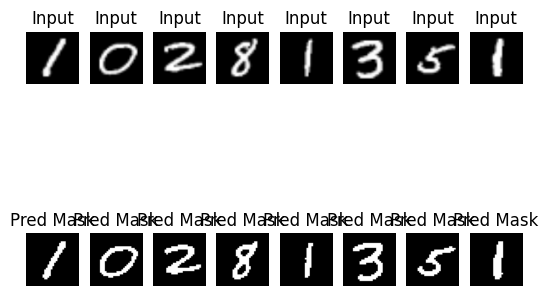

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# Step 1: Define a simple U-Net
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2, 2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU()
        )
        self.up = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )
        self.out_conv = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool(e1)
        e2 = self.enc2(p1)
        p2 = self.pool(e2)
        b = self.bottleneck(p2)
        u1 = self.up(b)
        cat1 = torch.cat([u1, e2], dim=1)
        d1 = self.dec1(cat1)
        out = torch.sigmoid(self.out_conv(d1))
        return out

# Step 2: Load MNIST dataset
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])
full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Step 3: Use only 200 images
subset_indices = list(range(200))
small_dataset = Subset(full_dataset, subset_indices)

# Step 4: 80–20 split
train_size = int(0.8 * len(small_dataset))
test_size = len(small_dataset) - train_size
train_set, test_set = random_split(small_dataset, [train_size, test_size])

trainloader = DataLoader(train_set, batch_size=8, shuffle=True)
testloader = DataLoader(test_set, batch_size=8, shuffle=False)

# Step 5: Initialize model
model = UNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Step 6: Train for 5 epochs
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, _ in trainloader:
        # Fake masks from thresholded images
        masks = (images > 0.5).float()
        # Resize masks to match model output size
        masks_resized = F.interpolate(masks, size=(32,32), mode="nearest")

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks_resized)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

print("Training complete!")

# Step 7: Visualize predictions
model.eval()
images, _ = next(iter(testloader))
with torch.no_grad():
    outputs = model(images)
pred_masks = (outputs > 0.5).float()

# Plot input and predicted masks
for i in range(len(images)):
    plt.subplot(2, len(images), i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title("Input")
    plt.axis("off")
    plt.subplot(2, len(images), i+1+len(images))
    plt.imshow(pred_masks[i][0], cmap="gray")
    plt.title("Pred Mask")
    plt.axis("off")
plt.show()
